In [69]:
import this

In [70]:
%run bsm_mcs_euro.py

Value of the European call option 8.012.


<Figure size 800x550 with 0 Axes>

## Time-to-Results

In [71]:
import numpy as np
import pandas as pd
from pylab import plt, mpl

In [72]:
plt.style.use("seaborn-v0_8")
mpl.rcParams['font.family'] = 'serif'
%config InlineBackend.figure_format = 'svg'

In [73]:
data = pd.read_csv('./../data/tr_eikon_eod_data.csv',
                           index_col=0, parse_dates=True)
data = pd.DataFrame(data['.SPX'])
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2138 entries, 2010-01-04 to 2018-06-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   .SPX    2138 non-null   float64
dtypes: float64(1)
memory usage: 33.4 KB


In [74]:
data['rets'] = np.log(data / data.shift(1))
data['vola'] = data['rets'].rolling(252).std() * np.sqrt(252)

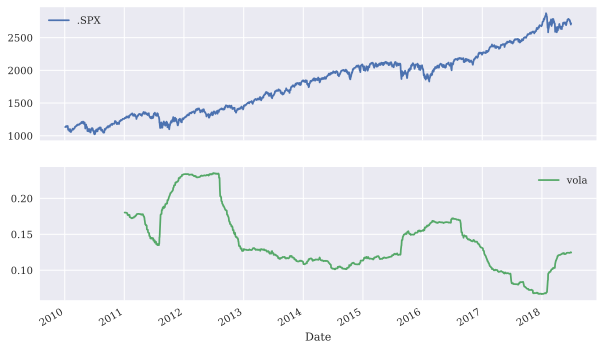

In [75]:
data[['.SPX', 'vola']].plot(subplots=True, figsize=(10, 6));

In [76]:
## Data-Driven Finance

In [ ]:
import numpy as np
import pandas as pd

In [79]:
data = pd.read_csv('http://hilpisch.com/tr_eikon_eod_data.csv',
                   index_col=0, parse_dates=True)
data = pd.DataFrame(data['AAPL.O'])
data['Returns'] = np.log(data / data.shift())
data.dropna(inplace=True)

In [80]:
lags = 6

In [81]:
cols = []
for lag in range(1, lags + 1):
    col = 'lag_{}'.format(lag)
    data[col] = np.sign(data['Returns'].shift(lag))
    cols.append(col)
data.dropna(inplace=True)

In [82]:
from sklearn.svm import SVC

In [83]:
model = SVC(gamma='scale')

In [85]:
data['Prediction'] = model.predict(data[cols])

NotFittedError: This SVC instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
data[['Returns', 'Strategy']].cumsum().apply(np.exp).plot(figsize=(10, 6));
plt.savefig('./images/AAPL_trading_strategy.png');